# Phase 2 — Exploratory Data Analysis (EDA)
### Personal Spending Intelligence System

**What this notebook does:**
Loads the transaction data from Phase 1 and systematically explores it using statistics and visualisations — answering the 6 key EDA questions before we build any model.

**What you will learn:**
- How to load and inspect a DataFrame
- Grouped aggregations (`groupby`)
- Summary statistics (`describe`)
- Outlier detection with the IQR method
- Plotting with matplotlib and seaborn
- How to compute and interpret a savings rate


## Step 1 — Imports and plot settings

Two new libraries appear here: `matplotlib` and `seaborn`. These are Python's main visualisation tools.
- `matplotlib` is the foundation — it draws everything.
- `seaborn` is built on top of matplotlib and makes statistical plots much easier and prettier.

Think of matplotlib as the pencil and seaborn as the stencil kit.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt      # plt is the standard alias — you will see this everywhere
import seaborn as sns                 # sns is the standard alias for seaborn
import warnings
warnings.filterwarnings('ignore')     # suppress minor warnings so output stays clean

# ── Plot style settings ────────────────────────────────────────────────────────
# These two lines make every plot in this notebook look clean and consistent.
# 'whitegrid' adds light horizontal gridlines — easier to read bar heights.
# figure.figsize sets the default canvas size in inches (width x height).
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

print("✅ Libraries ready")


✅ Libraries ready


## Step 2 — Load the data

We load the CSV saved in Phase 1. After loading, we always do a quick structural inspection:
- `shape` → how many rows and columns?
- `dtypes` → what type is each column?
- `isnull().sum()` → any missing values?
- `head()` → does it look right?

This is called a **sanity check** — you are making sure the data loaded correctly before doing any analysis on it.


In [2]:
df = pd.read_csv('data/transactions.csv', parse_dates=['date'])
# parse_dates=['date'] tells pandas to read the 'date' column as actual dates,
# not plain text. Without this, you cannot group by month or sort chronologically.

print("── Shape ──────────────────────────────")
print(f"  Rows: {df.shape[0]}   Columns: {df.shape[1]}")

print("\n── Column types ───────────────────────")
print(df.dtypes)

print("\n── Missing values ─────────────────────")
print(df.isnull().sum())

print("\n── First 5 rows ────────────────────────")
df.head()


── Shape ──────────────────────────────
  Rows: 820   Columns: 6

── Column types ───────────────────────
date           datetime64[us]
description               str
amount                  int64
category                  str
type                      str
month                     str
dtype: object

── Missing values ─────────────────────
date           0
description    0
amount         0
category       0
type           0
month          0
dtype: int64

── First 5 rows ────────────────────────


,date,description,amount,category,type,month
0,2024-01-01,Salary Credit — Connectivity Solutions,65000,Income,credit,2024-01
1,2024-01-01,Housing Society,18000,Rent,debit,2024-01
2,2024-01-01,Housing Society,18000,Rent,debit,2024-01
3,2024-01-01,BigBasket,710,Groceries,debit,2024-01
4,2024-01-03,Spotify,220,Subscriptions,debit,2024-01


## Step 3 — Separate income from expenses

The DataFrame contains both salary credits (income) and purchases (expenses) in the same `amount` column.
Before any analysis we split them — otherwise totals and averages would be meaningless.

**Key concept — boolean filtering:**
`df[df['type'] == 'debit']` means: *"give me only the rows where the type column equals 'debit'"*.
The condition inside `[]` returns True/False for each row, and pandas keeps only the True ones.


In [3]:
expenses = df[df['type'] == 'debit'].copy()
income   = df[df['type'] == 'credit'].copy()

# .copy() creates an independent copy so changes to 'expenses' don't affect 'df'
# Without .copy(), pandas sometimes warns you about editing a slice of the original

print(f"Total transactions : {len(df)}")
print(f"Expense rows       : {len(expenses)}")
print(f"Income rows        : {len(income)}")
print(f"\nTotal spent in 2024  : ₹{expenses['amount'].sum():,.0f}")
print(f"Total earned in 2024 : ₹{income['amount'].sum():,.0f}")
print(f"Net savings          : ₹{income['amount'].sum() - expenses['amount'].sum():,.0f}")


Total transactions : 820
Expense rows       : 808
Income rows        : 12

Total spent in 2024  : ₹621,220
Total earned in 2024 : ₹780,000
Net savings          : ₹158,780


## Step 4 — EDA Question 1: How is spending distributed across categories?

`groupby` is one of the most important operations in pandas. It works in 3 steps:
1. **Split** — group the rows by a column (here: `category`)
2. **Apply** — run a function on each group (here: `sum()`)
3. **Combine** — collect the results into a new Series

This is called the **split-apply-combine** pattern. You will use it in every data project you ever work on.


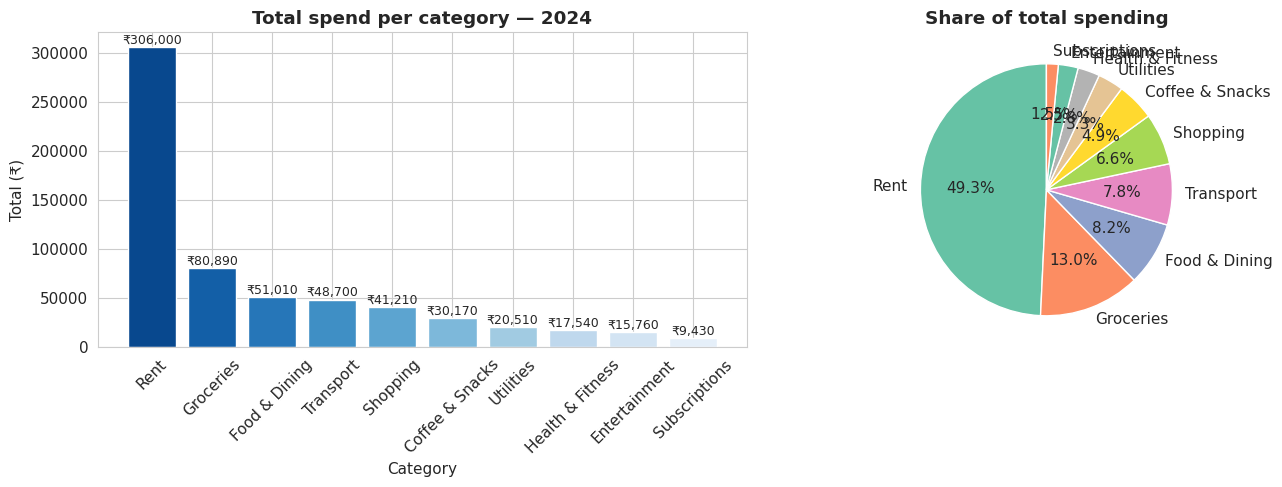


Top 3 spending categories:
  Rent                 ₹   306,000   (49.3% of total)
  Groceries            ₹    80,890   (13.0% of total)
  Food & Dining        ₹    51,010   (8.2% of total)


In [4]:
# Total spend per category, sorted largest first
category_spend = expenses.groupby('category')['amount'].sum().sort_values(ascending=False)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# plt.subplots(1, 2) creates a figure with 1 row and 2 columns of plots side by side
# axes[0] = left plot, axes[1] = right plot

# Left: bar chart of total spend
colors = sns.color_palette('Blues_r', len(category_spend))
# color_palette gives a list of colours; 'Blues_r' = blue shades, reversed (dark first)
bars = axes[0].bar(category_spend.index, category_spend.values, color=colors)
axes[0].set_title('Total spend per category — 2024', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total (₹)')
axes[0].tick_params(axis='x', rotation=45)  # rotate x labels so they don't overlap

# Add value labels on top of each bar
for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,   # x position = centre of bar
        bar.get_height() + 200,               # y position = just above bar top
        f"₹{bar.get_height():,.0f}",          # label text formatted with commas
        ha='center', va='bottom', fontsize=9
    )

# Right: pie chart — shows proportion of total budget
axes[1].pie(
    category_spend.values,
    labels=category_spend.index,
    autopct='%1.1f%%',        # show percentage with 1 decimal place
    startangle=90,            # rotate so first slice starts at the top
    colors=sns.color_palette('Set2', len(category_spend))
)
axes[1].set_title('Share of total spending', fontweight='bold')

plt.tight_layout()   # automatically adjusts spacing so labels don't overlap
plt.savefig('eda_category_spend.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 3 spending categories:")
for cat, amt in category_spend.head(3).items():
    pct = amt / category_spend.sum() * 100
    print(f"  {cat:<20} ₹{amt:>10,.0f}   ({pct:.1f}% of total)")


## Step 5 — EDA Question 2: Summary statistics per category

`describe()` returns 8 statistics for every numeric column in one line:
- **count** — how many transactions
- **mean** — average amount
- **std** — standard deviation (spread)
- **min / max** — range
- **25%, 50%, 75%** — quartiles (50% = median)

The difference between **mean** and **50% (median)** is important:
- If mean > median, a few large transactions are pulling the average up (right-skewed)
- If they are close, the distribution is fairly symmetric


In [5]:
stats = expenses.groupby('category')['amount'].describe().round(0)
# .round(0) rounds everything to 0 decimal places for readability

print("Per-category transaction statistics (₹):")
print(stats.to_string())

print("\n── Insight: most volatile categories (highest std dev) ──")
volatile = stats['std'].sort_values(ascending=False).head(5)
for cat, std in volatile.items():
    print(f"  {cat:<25}  std = ₹{std:,.0f}")


Per-category transaction statistics (₹):
                  count     mean    std      min      25%      50%      75%      max
category                                                                            
Coffee & Snacks   166.0    182.0   59.0     60.0    140.0    180.0    220.0    330.0
Entertainment      23.0    685.0  227.0    270.0    560.0    680.0    830.0   1130.0
Food & Dining     146.0    349.0  146.0     70.0    242.0    355.0    440.0    740.0
Groceries          97.0    834.0  217.0    280.0    680.0    850.0    960.0   1570.0
Health & Fitness   31.0    566.0  289.0    120.0    330.0    540.0    810.0   1090.0
Rent               17.0  18000.0    0.0  18000.0  18000.0  18000.0  18000.0  18000.0
Shopping           35.0   1177.0  625.0    240.0    780.0   1220.0   1500.0   2950.0
Subscriptions      48.0    196.0   19.0    160.0    180.0    200.0    210.0    240.0
Transport         221.0    220.0   95.0     40.0    150.0    220.0    280.0    490.0
Utilities          24.0 

## Step 6 — EDA Question 3: How does spending change month by month?

Time-series plots show **trends** and **seasonality**:
- A **trend** is a long-term direction (spending rising every month)
- **Seasonality** is a repeating pattern (spending spikes every December)

We group by `month` — the Period column we created in Phase 1 — and sum the amounts.
Then we plot it as a line chart with markers so each month's value is visible.


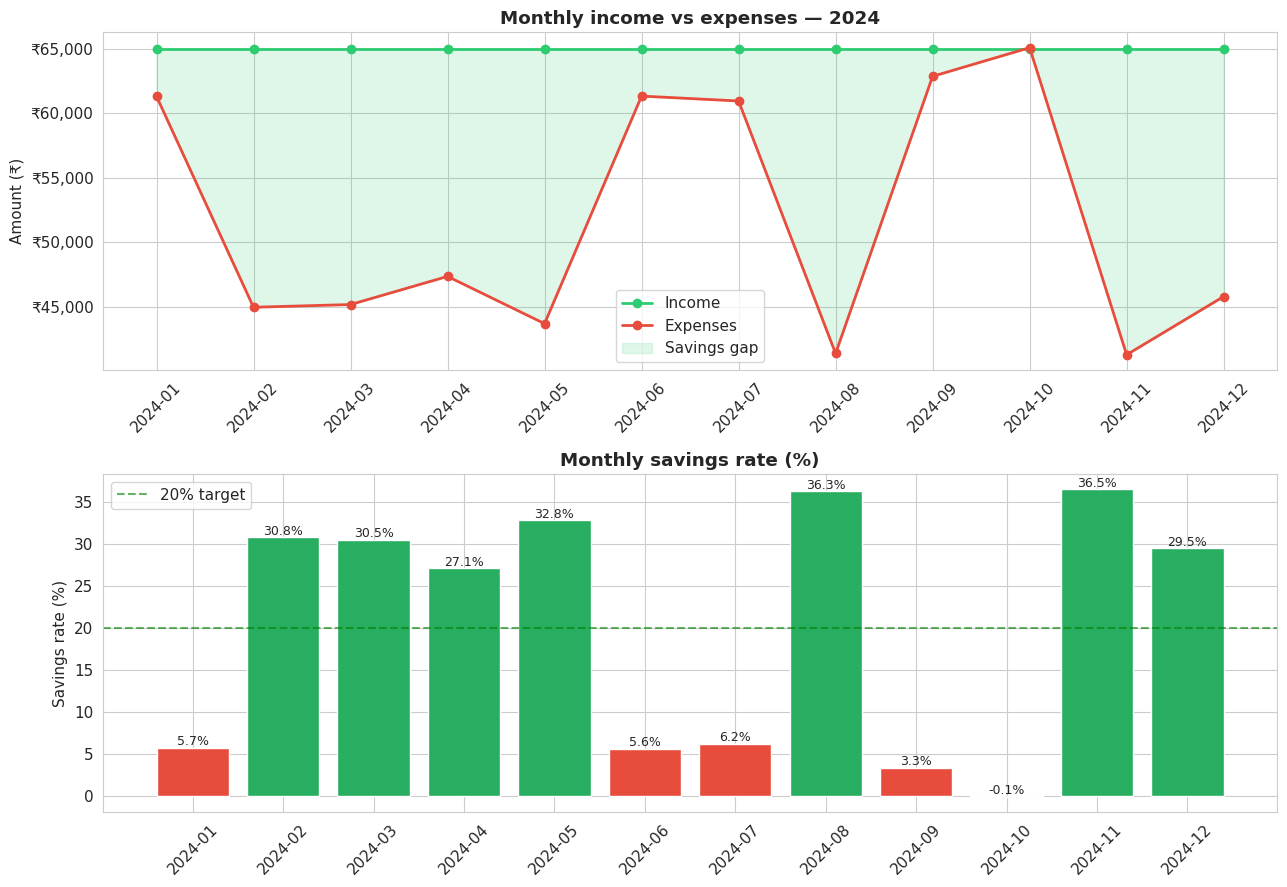

Average savings rate across 2024: 20.4%
Best month : 2024-11 (36.5%)
Worst month: 2024-10 (-0.1%)


In [6]:
monthly_expense = expenses.groupby('month')['amount'].sum()
monthly_income  = income.groupby('month')['amount'].sum()
monthly_savings = monthly_income - monthly_expense
savings_rate    = (monthly_savings / monthly_income * 100).round(1)

# Convert Period index to strings for cleaner x-axis labels
months_str = [str(m) for m in monthly_expense.index]

fig, axes = plt.subplots(2, 1, figsize=(13, 9))
# 2 rows, 1 column: top plot = spend vs income, bottom = savings rate

# ── Top plot: spending and income lines ───────────────────────────────────────
axes[0].plot(months_str, monthly_income.values,  marker='o', label='Income',   color='#2ecc71', linewidth=2)
axes[0].plot(months_str, monthly_expense.values, marker='o', label='Expenses', color='#e74c3c', linewidth=2)
axes[0].fill_between(months_str, monthly_expense.values, monthly_income.values,
                     alpha=0.15, color='#2ecc71', label='Savings gap')
# fill_between shades the area between the two lines — visually shows the savings gap
axes[0].set_title('Monthly income vs expenses — 2024', fontweight='bold')
axes[0].set_ylabel('Amount (₹)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{x:,.0f}'))
# FuncFormatter lets you customise how axis tick labels look

# ── Bottom plot: savings rate bar chart ───────────────────────────────────────
bar_colors = ['#27ae60' if v >= 20 else '#e67e22' if v >= 10 else '#e74c3c'
              for v in savings_rate.values]
# List comprehension: green if ≥20%, orange if ≥10%, red if below 10%
# This is a common pattern — colour-coding bars by a threshold

axes[1].bar(months_str, savings_rate.values, color=bar_colors)
axes[1].axhline(y=20, color='green', linestyle='--', alpha=0.6, label='20% target')
# axhline draws a horizontal reference line — here showing the 20% savings goal
axes[1].set_title('Monthly savings rate (%)', fontweight='bold')
axes[1].set_ylabel('Savings rate (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

for i, (month, rate) in enumerate(zip(months_str, savings_rate.values)):
    axes[1].text(i, rate + 0.3, f'{rate}%', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("Average savings rate across 2024:", f"{savings_rate.mean():.1f}%")
print("Best month :", savings_rate.idxmax(), f"({savings_rate.max():.1f}%)")
print("Worst month:", savings_rate.idxmin(), f"({savings_rate.min():.1f}%)")


## Step 7 — EDA Question 4: Are there outliers?

The **IQR (Interquartile Range) method** is the standard statistical way to detect outliers:

1. Q1 = 25th percentile (bottom quarter of values)
2. Q3 = 75th percentile (top quarter of values)
3. IQR = Q3 − Q1  (the middle 50% spread)
4. Anything beyond Q3 + 1.5×IQR is considered an outlier

Why 1.5? It is a rule of thumb from statistician John Tukey — it catches genuine outliers without being too aggressive.

A **box plot** visualises this automatically — the box is Q1 to Q3, the whiskers extend to 1.5×IQR, and dots beyond the whiskers are outliers.


Q1 = ₹190   Q3 = ₹552   IQR = ₹362
Outlier fence: above Rs.1,096
Outliers found: 51 transactions

      date       description      category  amount
2024-01-01   Housing Society          Rent   18000
2024-01-01   Housing Society          Rent   18000
2024-01-03  More Supermarket     Groceries    1120
2024-01-05             BWSSB     Utilities    1100
2024-01-05            Myntra      Shopping    1980
2024-01-08             Zepto     Groceries    1100
2024-01-29            Meesho      Shopping    1470
2024-02-01   Housing Society          Rent   18000
2024-02-18         BigBasket     Groceries    1110
2024-02-20            D-Mart     Groceries    1110
2024-02-26            Meesho      Shopping    2950
2024-03-01   Housing Society          Rent   18000
2024-03-07  More Supermarket     Groceries    1110
2024-03-10          Flipkart      Shopping    1890
2024-03-15             Nykaa      Shopping    1370
2024-04-01 Landlord Transfer          Rent   18000
2024-04-14            Amazon      S

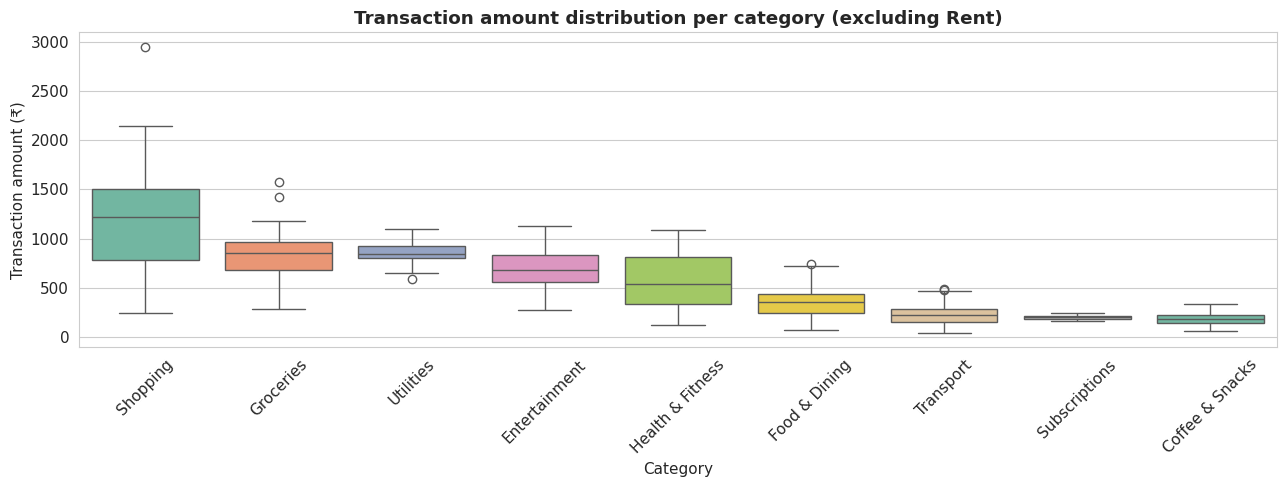

In [7]:
# ── Compute IQR outliers ───────────────────────────────────────────────────────
Q1  = expenses['amount'].quantile(0.25)   # 25th percentile
Q3  = expenses['amount'].quantile(0.75)   # 75th percentile
IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR   # anything below this is an outlier
upper_fence = Q3 + 1.5 * IQR   # anything above this is an outlier

outliers = expenses[expenses['amount'] > upper_fence]

print(f"Q1 = ₹{Q1:,.0f}   Q3 = ₹{Q3:,.0f}   IQR = ₹{IQR:,.0f}")
print(f"Outlier fence: above Rs.{upper_fence:,.0f}")
print(f"Outliers found: {len(outliers)} transactions\n")
print(outliers[['date','description','category','amount']].to_string(index=False))

# ── Box plots per category ─────────────────────────────────────────────────────
plt.figure(figsize=(13, 5))
# We exclude Rent here because its fixed ₹18,000 compresses the scale for everything else
no_rent = expenses[expenses['category'] != 'Rent']

sns.boxplot(data=no_rent, x='category', y='amount',
            palette='Set2',       # Set2 = a pleasant qualitative colour palette
            order=no_rent.groupby('category')['amount'].median().sort_values(ascending=False).index)
# 'order' sorts boxes by median — highest median category on the left

plt.title('Transaction amount distribution per category (excluding Rent)', fontweight='bold')
plt.xlabel('Category')
plt.ylabel('Transaction amount (₹)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('eda_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 8 — EDA Question 5: When do I spend on what? (Heatmap)

A **heatmap** shows two dimensions at once using colour intensity:
- Rows = spending categories
- Columns = months
- Colour = total spend (darker = more)

This is a powerful way to spot patterns like "Shopping always spikes in November" (Diwali sales) or "Transport is consistent year-round". This pattern recognition is exactly what the ML model will learn to do automatically in Phase 4.


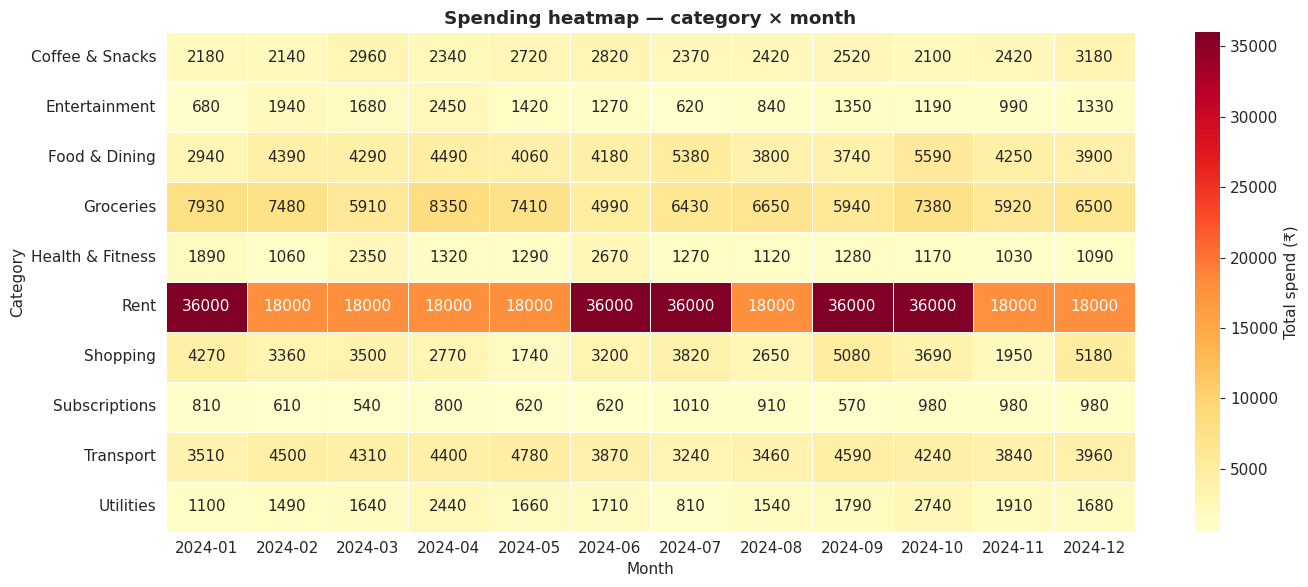

In [8]:
# Create a pivot table: rows = category, columns = month, values = total spend
pivot = expenses.pivot_table(
    index='category',      # what becomes the rows
    columns='month',       # what becomes the columns
    values='amount',       # what to aggregate
    aggfunc='sum'          # how to aggregate (sum all transactions in that cell)
).fillna(0)                # if a category had no spend in a month, fill with 0

# Convert column names to strings for cleaner display
pivot.columns = [str(m) for m in pivot.columns]

plt.figure(figsize=(14, 6))
sns.heatmap(
    pivot,
    cmap='YlOrRd',          # Yellow → Orange → Red: low to high spend
    fmt='.0f',              # format numbers as integers (no decimals)
    annot=True,             # annot=True prints the number inside each cell
    linewidths=0.5,         # thin white lines between cells for readability
    cbar_kws={'label': 'Total spend (₹)'}  # label the colour bar
)
plt.title('Spending heatmap — category × month', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('eda_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 9 — EDA Summary and key insights

Good data science is not just running code — it is turning numbers into sentences a stakeholder can act on. This cell documents the insights we found. In a real job, this becomes your slide deck or report.


In [9]:
print("=" * 55)
print("EDA FINDINGS — Personal Spending Intelligence System")
print("=" * 55)

total_spend  = expenses['amount'].sum()
total_income = income['amount'].sum()
avg_savings  = savings_rate.mean()

lines = [
    "",
    "Dataset",
    f"  Period       : Jan 2024 - Dec 2024",
    f"  Transactions : {len(expenses)} expense rows + {len(income)} income rows",
    "",
    "Spending overview",
    f"  Total earned : Rs. {total_income:>12,.0f}",
    f"  Total spent  : Rs. {total_spend:>12,.0f}",
    f"  Net saved    : Rs. {total_income - total_spend:>12,.0f}",
    f"  Avg savings  : {avg_savings:.1f}% per month",
    "",
    "Top cost drivers",
    f"  1. {category_spend.index[0]:<18} Rs. {category_spend.iloc[0]:>10,.0f}  ({category_spend.iloc[0]/total_spend*100:.1f}%)",
    f"  2. {category_spend.index[1]:<18} Rs. {category_spend.iloc[1]:>10,.0f}  ({category_spend.iloc[1]/total_spend*100:.1f}%)",
    f"  3. {category_spend.index[2]:<18} Rs. {category_spend.iloc[2]:>10,.0f}  ({category_spend.iloc[2]/total_spend*100:.1f}%)",
    "",
    f"Outliers detected : {len(outliers)} transactions above Rs. {upper_fence:,.0f}",
    "",
    "Next step: Phase 3 - Feature Engineering",
    "  rolling averages, month-over-month change, category ratios, and more.",
]
print(chr(10).join(lines))


EDA FINDINGS — Personal Spending Intelligence System

Dataset
  Period       : Jan 2024 - Dec 2024
  Transactions : 808 expense rows + 12 income rows

Spending overview
  Total earned : Rs.      780,000
  Total spent  : Rs.      621,220
  Net saved    : Rs.      158,780
  Avg savings  : 20.4% per month

Top cost drivers
  1. Rent               Rs.    306,000  (49.3%)
  2. Groceries          Rs.     80,890  (13.0%)
  3. Food & Dining      Rs.     51,010  (8.2%)

Outliers detected : 51 transactions above Rs. 1,096

Next step: Phase 3 - Feature Engineering
  rolling averages, month-over-month change, category ratios, and more.
